# Olist E-Commerce Customer Satisfaction Analysis
**Author:** Nicole  
**Dataset:** Olist Brazilian E-Commerce, 2016-2018  
**Tools:** Python, pandas, scikit-learn, plotly, SQL

Ever since PinDuoDuo rolled out the 'free shipping to Singapore, no minimum spend' initiative, I have gotten increasingly addicted to shopping on the platform. I am not alone - my mother has placed over 50 orders in a week, and my aunty has been showing everyone her cheap deals she got from the platform. It led me to wonder, what exactly is driving these purchases? Is it price, delivery or something more? While Olist operates in a different market, it offers a rich dataset to test whether price, delivery or other factors drive customer satisfaction and retention. With 8 different tables covering many aspects of orders, it provided enough room to explore different factors that potentially contribute to satisfaction and repeat purchases.

This project investigates three hypotheses:

1. Does higher satisfaction lead to repeat purchases?
2. Does lower price lead to higher satisfaction?
3. Does meeting the estimated delivery date or faster raw delivery speed lead to higher satisfaction?

Key analyses are reproduced in SQL alongside Python to demonstrate proficiency across both tools

**Section 1:** Data cleaning

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud
import matplotlib.pyplot as plt

orders    = pd.read_csv('data/olist_orders_dataset.csv')
items     = pd.read_csv('data/olist_order_items_dataset.csv')
payments  = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews   = pd.read_csv('data/olist_order_reviews_dataset.csv')
customers = pd.read_csv('data/olist_customers_dataset.csv')
products  = pd.read_csv('data/olist_products_dataset.csv')
sellers   = pd.read_csv('data/olist_sellers_dataset.csv')
trans = pd.read_csv('data/product_category_name_translation.csv')

pd.set_option('display.max_columns', None)

In [185]:
# Initialise for sql
import sqlite3

conn = sqlite3.connect('olist.db')

orders.to_sql('orders', conn, if_exists='replace', index=False)
items.to_sql('items', conn, if_exists='replace', index=False)
payments.to_sql('payments', conn, if_exists='replace', index=False)
reviews.to_sql('reviews', conn, if_exists='replace', index=False)
customers.to_sql('customers', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
sellers.to_sql('sellers', conn, if_exists='replace', index=False)

3095

In [186]:
# Checking datatypes, converting for use
for name, df in [('orders', orders), ('items', items), 
                 ('payments', payments), ('reviews', reviews)]:
    print(f"\n{'='*40}")
    print("-")
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} cols")
    print("--")
    print(df.dtypes)
    print("---")
    print(df.isnull().sum())


-
orders: 99441 rows, 8 cols
--
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object
---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

-
items: 112650 rows, 7 cols
--
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object
---
order_id               0
order_item_id          0
product_id        

In [187]:
# Make the dates to datetime format
tables = {
    'orders': orders,
    'items': items,
    'reviews': reviews
}

date_cols = {
    'orders': ['order_purchase_timestamp', 'order_approved_at',
               'order_delivered_carrier_date', 'order_delivered_customer_date',
               'order_estimated_delivery_date'],
    'items':  ['shipping_limit_date'],
    'reviews': ['review_creation_date', 'review_answer_timestamp']
}

for df_name, cols in date_cols.items():
    df = tables[df_name]
    for col in cols:
        df[col] = pd.to_datetime(df[col])

print(orders.dtypes)

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [188]:
# Checking orders vs payment correspondence
orders_with_payment = payments['order_id'].nunique()
total_orders = orders['order_id'].nunique()

print(f"Orders with payment: {orders_with_payment}")
print(f"Total orders: {total_orders}")
print(f"Difference: {total_orders - orders_with_payment}")

payments_with_no_order = payments[~payments['order_id'].isin(orders['order_id'])]
print(len(payments_with_no_order))

Orders with payment: 99440
Total orders: 99441
Difference: 1
0


In [189]:
# Checking the difference
orders_with_no_payment = orders[~orders['order_id'].isin(payments['order_id'])]
print(orders_with_no_payment[['order_id', 'order_status']])

                               order_id order_status
30710  bfbd0f9bdef84302105ad712db648a6c    delivered


Anormally: order with no payment should not be delivered, exclude from payment related analysis

In [190]:
# Checking order status
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total not delivered = total null in order_delivered_customer_date. Should not drop null as it is informative.

**Section 2:** Hypothesis 1: Does satisfaction drive repeat purchases?

**Section 2.1:** Exploring how common repeat purchases are

In [191]:
# Find number of repeat orders
no_unique_cus = customers['customer_unique_id'].nunique()
repeat_orders = total_orders - no_unique_cus
print(repeat_orders)

3345


3345 repeat orders, some are from the same customer.

In [192]:
# Find number of repeat customers
#pandas version
customer_and_order = pd.merge(customers, orders, on='customer_id')
count_each = customer_and_order.groupby('customer_unique_id')['order_id'].count()
repeat = count_each[count_each>1]
print(len(repeat))
print(customer_and_order['customer_unique_id'].nunique())

2997
96096


In [193]:
#sql version
pd.read_sql_query("""
    WITH joined AS(
        SELECT customer_unique_id, order_id
        FROM orders
        JOIN customers ON orders.customer_id = customers.customer_id
    )
    SELECT customer_unique_id, COUNT(*) as order_count
    FROM joined
    GROUP BY customer_unique_id
    HAVING COUNT(*)>1
""", conn)

,customer_unique_id,order_count
0,00172711b30d52eea8b313a7f2cced02,2
1,004288347e5e88a27ded2bb23747066c,2
2,004b45ec5c64187465168251cd1c9c2f,2
3,0058f300f57d7b93c477a131a59b36c3,2
4,00a39521eb40f7012db50455bf083460,2
...,...,...
2992,ff36be26206fffe1eb37afd54c70e18b,3
2993,ff44401d0d8f5b9c54a47374eb48c1b8,2
2994,ff8892f7c26aa0446da53d01b18df463,2
2995,ff922bdd6bafcdf99cb90d7f39cea5b3,3


Both pandas and sql give 2997 repeat customers. about 3% repeat purchases, rather low. Olist seems to be a one-time purchase platform

**Section 2.2:** Test hypothesis: Higher review scores should encourage more repeat purchases

In [194]:
# Explore distribution of review scores
reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

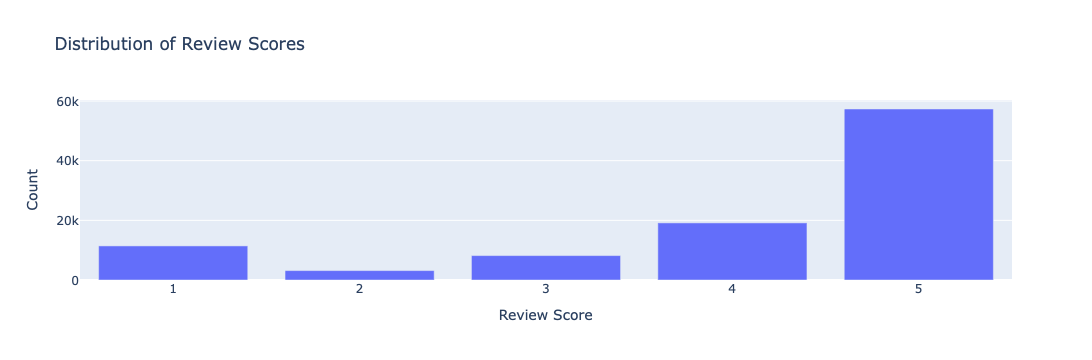

In [195]:
import plotly.express as px
review_counts = reviews['review_score'].value_counts().reset_index() #convert to dataframe
review_counts.columns = ['review_score', 'count'] #set column labels
fig = px.bar(review_counts, 
             x='review_score', 
             y='count',
             title='Distribution of Review Scores',
             labels={'count': 'Count',
                     'review_score': 'Review Score'})
review_counts = review_counts.sort_values('review_score')
fig.show()

Skewed data with majority review score of 5. Have to note this imbalance when implementing models

In [196]:
# Find total number of repeats for satisfied & non-satisfied
customer_and_order_and_review = pd.merge(customer_and_order, reviews, on='order_id')
customer_and_order_and_review['is_repeat'] = customer_and_order_and_review['customer_unique_id'].isin(repeat.index)
customer_and_order_and_review['is_satisfied'] = customer_and_order_and_review['review_score'] == 5
print(customer_and_order_and_review[['is_repeat', 'is_satisfied']].value_counts())

is_repeat  is_satisfied
False      True            53259
           False           39217
True       True             4069
           False            2679
Name: count, dtype: int64


Observed that total number of repeats is much more than number of repeat customers because each order has its own review. For a more accurate comparison, I only keep the review of the first order and check if it belongs to a repeat customer.

In [197]:
# Only keep review of first order
order_sorted = orders.sort_values(by='order_purchase_timestamp')
order_and_review = pd.merge(order_sorted, reviews, on='order_id')
customer_and_order_and_review = pd.merge(order_and_review, customers, on='customer_id')
customer_and_order_and_review.drop_duplicates(subset=['customer_unique_id'], keep='first', inplace=True)
print(customer_and_order_and_review.shape)
customer_and_order_and_review['is_repeat'] = customer_and_order_and_review['customer_unique_id'].isin(repeat.index)
customer_and_order_and_review['is_satisfied'] = customer_and_order_and_review['review_score'] == 5
print(customer_and_order_and_review[['is_repeat', 'is_satisfied']].value_counts())

(95380, 18)
is_repeat  is_satisfied
False      True            53207
           False           39185
True       True             1789
           False            1199
Name: count, dtype: int64


Number smaller than total number of order. 716 orders have no reviews, excluded from analysis

Percentage of satisfied customers who repeat = 3.25%.
Percentage of unsatisfied customers who repeat = 2.97%.
Satisfaction nudges repeat purchses slightly but not much, suggests retention is driven by other factors

**Section 3:** Hypothesis 2: Does lower price lead to higher satisfaction?

**Section 3.1:** Explore distribution of prices

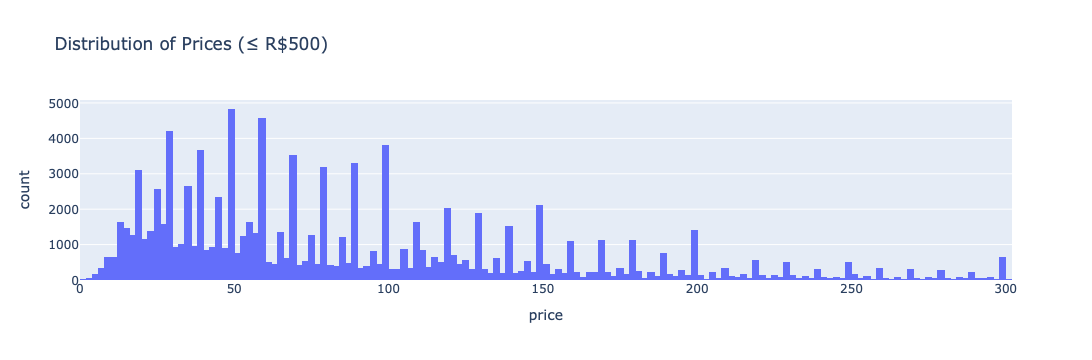

In [198]:
# Get distribution of prices
px.histogram(items[items['price'] <= 300], x='price', title='Distribution of Prices (≤ R$500)')

Spikes reflect psychological pricing where sellers set prices just below multiples of 10. Generally. it is not really a low-price platform as the peak is around $50 with a long tail extending to thousands of dollars.

In [199]:
# Find average total cost for each review score

#pandas version
price_and_review = pd.merge(items, reviews, on='order_id')
price_and_review['total cost'] = price_and_review['price']+price_and_review['freight_value']
ave_price = price_and_review.groupby('review_score')[['total cost']].mean()
print(ave_price)

              total cost
review_score            
1             148.564213
2             136.793110
3             130.345649
4             138.655633
5             140.790630


In [200]:
#sql version
pd.read_sql_query("""
    WITH joined AS (
        SELECT reviews.review_score, items.price, items.freight_value
        FROM items
        JOIN reviews ON reviews.order_id = items.order_id
    )
    SELECT review_score, AVG(price + freight_value) AS total_cost
    FROM joined
    GROUP BY review_score
""", conn)


,review_score,total_cost
0,1,148.564213
1,2,136.793110
2,3,130.345649
3,4,138.655633
4,5,140.790630


No clear pattern. Price not a good predictor of satisfaction

**Section 3.2:** Perhaps product category is related to satisfaction?

In [201]:
# Explore average rating for each category
prod_items = pd.merge(products, items, on = 'product_id')
prod_items_rev = pd.merge(prod_items, reviews, on = 'order_id')
prod_items_rev_t = pd.merge(prod_items_rev, trans, on = 'product_category_name')
ave_rate = prod_items_rev_t.groupby('product_category_name_english')['review_score'].mean()
ave_rate = ave_rate.sort_values(ascending=False)
print(ave_rate)

product_category_name_english
cds_dvds_musicals            4.642857
fashion_childrens_clothes    4.500000
books_general_interest       4.446266
costruction_tools_tools      4.444444
flowers                      4.419355
                               ...   
fashion_male_clothing        3.641221
home_comfort_2               3.629630
office_furniture             3.493183
diapers_and_hygiene          3.256410
security_and_services        2.500000
Name: review_score, Length: 71, dtype: float64


In [202]:
# Exploring any categories with few reviews (lack representation)
no_each_cat = prod_items_rev_t.groupby('product_category_name_english')['review_score'].count().sort_values()
no_each_cat

product_category_name_english
security_and_services            2
fashion_childrens_clothes        8
la_cuisine                      13
cds_dvds_musicals               14
arts_and_craftmanship           24
                             ...  
computers_accessories         7849
furniture_decor               8331
sports_leisure                8640
health_beauty                 9645
bed_bath_table               11137
Name: review_score, Length: 71, dtype: int64

Some categories have very few reviews, need to exclude them due to small sample bias. Find threshold at 25th percentile

In [203]:
# Find 25th percentile
counts = prod_items_rev_t.groupby('product_category_name_english')['review_score'].count()
threshold = counts.quantile(0.25)
print(threshold)

90.0


In [204]:
# Exclude categories lower than 25th percentile
cat_include = no_each_cat[no_each_cat>90].index
ave_rate_inc = ave_rate[ave_rate.index.isin(cat_include)]
print(ave_rate_inc)

product_category_name_english
books_general_interest                     4.446266
costruction_tools_tools                    4.444444
books_technical                            4.368421
food_drink                                 4.315412
luggage_accessories                        4.315257
fashion_shoes                              4.233716
food                                       4.218182
stationery                                 4.193857
pet_shop                                   4.185147
computers                                  4.175000
home_appliances                            4.172457
perfumery                                  4.161941
toys                                       4.158641
musical_instruments                        4.152593
small_appliances                           4.149188
cool_stuff                                 4.146341
fashion_bags_accessories                   4.144679
home_appliances_2                          4.142857
health_beauty                     

Top satisfaction categories tend to include lighter smaller items (books, tools, food) whlie bottom categories tend to include heavier items (furniture, fixed telephone). Could it be because they are easier for faster delivery?

In [205]:
# Explore if there is a relationship between category and delivery time
delivery_and_review_and_items = pd.merge(delivery_and_review, prod_items_rev_t, on='order_id')
duration_by_cat = delivery_and_review_and_items.groupby('product_category_name_english')['delivery_duration'].mean()
duration_by_cat_filtered = duration_by_cat[duration_by_cat.index.isin(cat_include)]
duration_by_cat_filtered.sort_values()

product_category_name_english
construction_tools_lights                  9 days 12:36:09.410169
food                                       9 days 13:54:48.655030
signaling_and_security                    10 days 07:31:34.545918
drinks                                    10 days 10:54:50.713136
construction_tools_construction           10 days 15:31:24.400218
luggage_accessories                       10 days 15:36:52.794967
books_technical                           10 days 15:51:18.746268
industry_commerce_and_business            10 days 17:56:27.897727
food_drink                                10 days 19:15:07.647272
small_appliances                          10 days 19:50:09.193984
housewares                                10 days 21:59:01.210896
fashion_bags_accessories                  11 days 03:40:45.153959
pet_shop                                  11 days 04:32:45.720458
home_appliances                           11 days 04:38:58.626006
art                                       11 d

Office furniture has longest delivery and is the worst rated category. Tools and books have relatively short deliveries and is rated quite highly. It is possible there is a correlation between bulkier categories, their delivery duration and satisfaction, but it does not seem very prominent.

**Section 4:** Hypothesis 3: Does delivery affect satisfaction?

2 factors to investigate: whether delivery met estimated delivery date and absolute delivery speed. I hypothesise that whether delivery met estimated delivery date is a stronger predictor.

**Section 4.1:** Explore average early delivery and delivery duration

In [206]:
# Explore early delivery and delivery duration on average
orders['delivery_delay'] = orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']
orders['delivery_duration'] = orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']
print(orders[['delivery_delay', 'delivery_duration']].describe())

                  delivery_delay        delivery_duration
count                      96476                    96476
mean   -12 days +19:42:04.042384  12 days 13:24:31.879068
std      10 days 04:28:00.181984   9 days 13:07:00.181125
min          -147 days +23:36:47          0 days 12:48:07
25%    -17 days +18:08:05.250000   6 days 18:23:37.250000
50%    -12 days +01:13:31.500000         10 days 05:13:34
75%            -7 days +14:38:24  15 days 17:17:16.250000
max            188 days 23:24:07        209 days 15:05:12


Orders on average arrive 12 days early, 2x of actual duration. Suggests Olist overestimates delivery times so many customers receive early. Perhaps raw duration may matter more?

**Section 4.2**: Explore average early delivery and delivery duration for each review score

In [207]:
# Investigate how reviews change with respect to the 2 factors 
delivery_and_review = pd.merge(orders, reviews, on='order_id')
print(delivery_and_review.shape)
ave_delivery_duration = delivery_and_review.groupby('review_score')['delivery_duration'].mean()
ave_delivery_early = delivery_and_review.groupby('review_score')['delivery_delay'].mean()
print(ave_delivery_duration, ave_delivery_early)

(99224, 16)
review_score
1   21 days 07:28:26.611967
2   16 days 15:51:14.100306
3   14 days 06:17:13.556016
4   12 days 07:29:47.568125
5   10 days 16:31:35.505432
Name: delivery_duration, dtype: timedelta64[us] review_score
1    -4 days +15:06:17.729940
2    -8 days +01:29:14.509351
3   -11 days +22:06:58.198694
4   -12 days +07:34:55.792806
5   -13 days +07:28:45.493867
Name: delivery_delay, dtype: timedelta64[us]


Higher satisfaction attributed to shorter delivery time and early deliveries. Between 1-star and 5-star, difference in average duration is 11 days while difference in early delivery is 9 days, suggesting raw delivery timings are stronger predictors of satisfaction.

   review_score  avg_delivery_days
0             1                 21
1             2                 16
2             3                 14
3             4                 12
4             5                 10


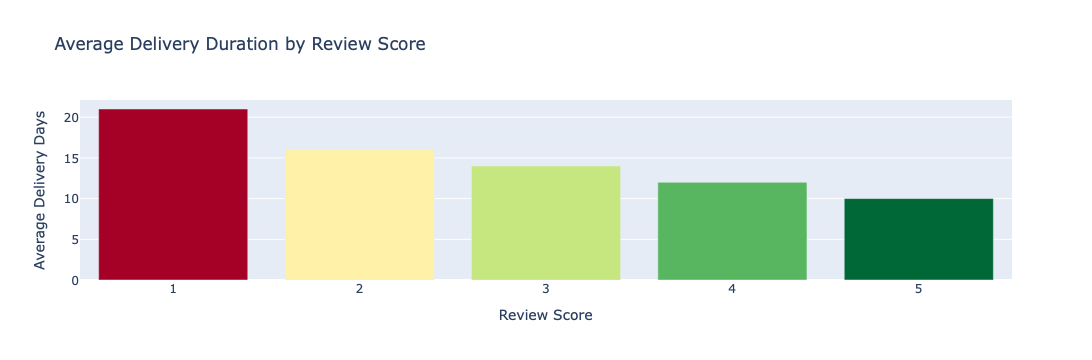

In [208]:
# Plot graph of average delivery duration by review score
import plotly.express as px
df_viz = ave_delivery_duration.reset_index()
df_viz.columns = ['review_score', 'avg_delivery_days']
df_viz['avg_delivery_days'] = df_viz['avg_delivery_days'].dt.days
print(df_viz)
fig = px.bar(df_viz, 
             x='review_score', 
             y='avg_delivery_days',
             title='Average Delivery Duration by Review Score',
             labels={'avg_delivery_days': 'Average Delivery Days',
                     'review_score': 'Review Score'},
             color='avg_delivery_days',
             color_continuous_scale='RdYlGn_r')
fig.update_layout(coloraxis_showscale=False)
fig.show()

In [209]:
#sql version
pd.read_sql_query("""
    WITH joined AS (
        SELECT orders.order_purchase_timestamp, reviews.review_score, orders.order_delivered_customer_date
        FROM orders
        JOIN reviews ON orders.order_id = reviews.order_id
        WHERE orders.order_delivered_customer_date IS NOT NULL
    ),
    with_duration AS (
        SELECT review_score, ROUND(julianday(order_delivered_customer_date) - 
             julianday(order_purchase_timestamp)) as delivery_duration_days
        FROM joined
    )

    SELECT review_score, AVG(delivery_duration_days) as avg_delivery_days
    FROM with_duration
    GROUP BY review_score
    ORDER BY review_score
""", conn)

,review_score,avg_delivery_days
0,1,21.268466
1,2,16.618837
2,3,14.223311
3,4,12.270448
4,5,10.647371


**Section 4:** Modelling

This section aims to use 2 models, random forest and logistic regression to investigate the important factors that affect satisfaction.

**Section 4.1:** Random forest

In [210]:
# Using table created before
print(delivery_and_review_and_items.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay', 'delivery_duration', 'review_id_x', 'review_score_x', 'review_comment_title_x', 'review_comment_message_x', 'review_creation_date_x', 'review_answer_timestamp_x', 'product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'order_item_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'review_id_y', 'review_score_y', 'review_comment_title_y', 'review_comment_message_y', 'review_creation_date_y', 'review_answer_timestamp_y', 'product_category_name_english']


In [211]:
# Initialising for model
delivery_and_review_and_items['delivery_duration_days'] = delivery_and_review_and_items['delivery_duration'].dt.days
delivery_and_review_and_items['delivery_delay_days'] = delivery_and_review_and_items['delivery_delay'].dt.days
features = ['delivery_duration_days', 'delivery_delay_days', 'price', 'freight_value', 'product_category_name_english']
target = 'review_score_x'
df_model = delivery_and_review_and_items[features + [target]].dropna()
df_model['satisfied'] = (df_model[target] == 5).astype(int)
print(df_model.shape)
print(df_model['satisfied'].value_counts())

(109739, 7)
satisfied
1    63172
0    46567
Name: count, dtype: int64


In [212]:
# One-hot encoding of categories
df_model = pd.get_dummies(df_model, columns=['product_category_name_english'])
print(df_model.shape)

(109739, 77)


In [213]:
# Test-train split
X = df_model.drop(columns=['satisfied', 'review_score_x']) #redundant information
y = df_model['satisfied']
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 1)
print(X_train.shape, X_test.shape)

(87791, 75) (21948, 75)


In [214]:
# Implement model, get confusion matrix
rf = RandomForestClassifier(n_estimators=100, random_state=1, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.50      0.56      9272
           1       0.68      0.79      0.73     12676

    accuracy                           0.67     21948
   macro avg       0.66      0.64      0.64     21948
weighted avg       0.66      0.67      0.66     21948



Accuracy 0.67 vs 0.58 if all predicted as satisfied. 9% increase shows the model is learning a pattern, but not much. Recall for 0 (catching unsatisfied customers) is 0.50 which is a coin toss. Suggests irreductible errors from factors not in data.

In [215]:
# Get important features
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).head(10)

price                                           0.260126
freight_value                                   0.259895
delivery_delay_days                             0.226632
delivery_duration_days                          0.154776
product_category_name_english_housewares        0.004755
product_category_name_english_auto              0.004231
product_category_name_english_watches_gifts     0.003819
product_category_name_english_garden_tools      0.003751
product_category_name_english_sports_leisure    0.003589
product_category_name_english_baby              0.003569
dtype: float64

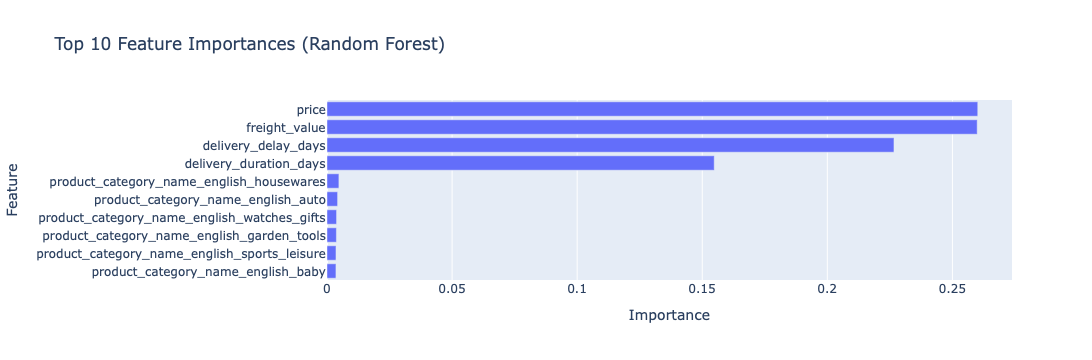

In [216]:
fig = px.bar(
    importances.sort_values(ascending=True).tail(10),
    orientation='h',
    title='Top 10 Feature Importances (Random Forest)',
    labels={'value': 'Importance', 'index': 'Feature'}
)
fig.update_layout(showlegend=False)
fig.show()

Model itentifies price and freight as the largest factors, followed by delivery experience. This contradicts with EDA which showed no linear relationship between price and satisfaction. The model might have picked up on some non-linear patterns. Cost might also be correlated to product type and delivery rather than directly driving satisfaction.

**Section 4.2:** Logistic regression

In [217]:
# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # do not fit as test should be unseen

In [218]:
# Implement and get confusion matrix
lr = LogisticRegression(max_iter=5000, random_state=1)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.62      0.29      0.40      9272
           1       0.63      0.87      0.73     12676

    accuracy                           0.62     21948
   macro avg       0.62      0.58      0.56     21948
weighted avg       0.62      0.62      0.59     21948



Accuracy (0.62) and recall for 0 (0.29) are lower than that of Random Forests. It suggests the relationships in the data are non-linear. 

In [219]:
# Get important features 
coef = pd.Series(lr.coef_[0], index=X_train.columns)
coef.sort_values(ascending=False).head(10)
print(coef.sort_values().head(10))
coef.sort_values(ascending=False).head(10)

delivery_duration_days                                -0.484668
delivery_delay_days                                   -0.120259
product_category_name_english_office_furniture        -0.064942
product_category_name_english_bed_bath_table          -0.057919
product_category_name_english_telephony               -0.033209
product_category_name_english_furniture_decor         -0.031781
product_category_name_english_fixed_telephony         -0.025034
product_category_name_english_computers_accessories   -0.024074
product_category_name_english_security_and_services   -0.023571
product_category_name_english_home_construction       -0.022721
dtype: float64


product_category_name_english_books_general_interest       0.048655
product_category_name_english_perfumery                    0.045285
freight_value                                              0.043464
product_category_name_english_stationery                   0.039842
product_category_name_english_health_beauty                0.039575
price                                                      0.036043
product_category_name_english_toys                         0.035012
product_category_name_english_fashion_childrens_clothes    0.033623
product_category_name_english_sports_leisure               0.032488
product_category_name_english_books_technical              0.030550
dtype: float64

Delivery duration has highest correlation with satisfaction, consistent with EDA. Price positvely correlated with satisfaction, a little counterintuitive. Perhaps higher price signals higher quality. Feight value also positively correlated with satisfaction, might indicate premium delivery or heavy items that arrived on time. Consistent with earlier finding that price and freight together act as a proxy for product complexity rather than directly driving satisfaction

Some key signals that are consistent with EDA:
Longer delivery → dissatisfaction
Books → satisfaction
Office furniture → dissatisfaction

**Section 4.3:** Natural Language Processing of Reviews

In [220]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords') #filler words, exclude from analysis
print(stopwords.words('portuguese')[:20])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nicolekhor/nltk_data...


['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'às', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele']


[nltk_data]   Package stopwords is already up-to-date!


In [221]:
# Check if number of reviews is enough for analysis
one_star = reviews[reviews['review_score'] == 1]['review_comment_message'].dropna()
five_star = reviews[reviews['review_score'] == 5]['review_comment_message'].dropna()

print(f"1-star comments: {len(one_star)}")
print(f"5-star comments: {len(five_star)}")

1-star comments: 8745
5-star comments: 20554


In [222]:
# Find top 20 words in 1-star reviews

pt_stopwords = stopwords.words('portuguese')

vectorizer = CountVectorizer(stop_words=pt_stopwords, max_features=20) #ignore filler words, count number of times each word appears in review

one_star_matrix = vectorizer.fit_transform(one_star)
one_star_words = pd.Series(
    one_star_matrix.toarray().sum(axis=0), #total count of words across all reviews, axis=0 means add up each column
    index=vectorizer.get_feature_names_out()
).sort_values(ascending=False)

print("Top 20 words in 1-star reviews:")
print(one_star_words)

Top 20 words in 1-star reviews:
produto      5081
recebi       2783
comprei      1560
ainda        1181
veio         1121
entregue     1113
entrega      1082
chegou        944
nao           821
compra        762
prazo         702
pedido        657
loja          635
dia           632
agora         631
nada          475
lannister     471
quero         467
apenas        437
pois          424
dtype: int64


'ainda', 'veio', 'entregue', 'entrega', 'chegou' and 'prazo' are all delivery-related words. 6 out of the top 20 words are related to delivery. Customers seem to be complaining about waiting and non-delivery.

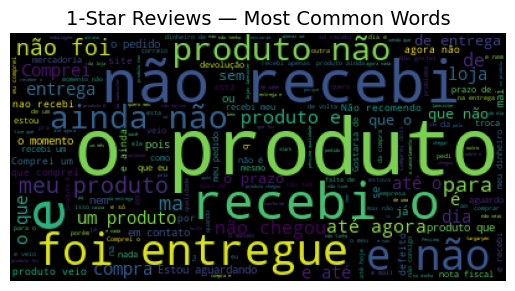

In [223]:
# Visual representation of common words of 1-star reviews

text = ' '.join(one_star)
wordcloud = WordCloud().generate(text)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('1-Star Reviews — Most Common Words', fontsize=14)
wordcloud = WordCloud(stopwords=set(pt_stopwords)).generate(text)
plt.show()

In [224]:
# Find top 20 words in 5-star reviews

five_star_matrix = vectorizer.fit_transform(five_star)
five_star_words = pd.Series(
    five_star_matrix.toarray().sum(axis=0), #total count of words across all reviews, axis=0 means add up each column
    index=vectorizer.get_feature_names_out()
).sort_values(ascending=False)

print("Top 20 words in 5-star reviews:")
print(five_star_words)

Top 20 words in 5-star reviews:
produto      8117
prazo        5703
antes        4525
entrega      3699
recomendo    3328
chegou       3219
bom          2954
bem          2200
qualidade    1756
entregue     1675
tudo         1648
excelente    1624
ótimo        1530
super        1480
loja         1175
rápida       1153
gostei       1052
recebi       1049
compra        876
parabéns      842
dtype: int64


'prazo', 'antes', 'entrega', 'chegou', 'entregue', 'rápida' are delivery-related words. 6 out of the top 20 are related to delivery. Customers seem to be complimenting fast delivery.

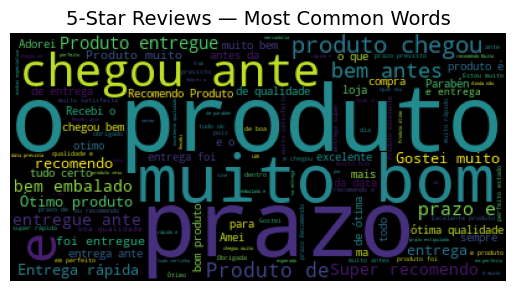

In [225]:
# Visual representation of common words of 5-star reviews

text = ' '.join(five_star)
wordcloud = WordCloud().generate(text)
plt.imshow(wordcloud)
plt.axis('off')
plt.title('5-Star Reviews — Most Common Words', fontsize=14)
wordcloud = WordCloud(stopwords=set(pt_stopwords)).generate(text)
plt.show()

NLP analysis of review comments confirm that delivery is a main factor in a customer's satisfaction. 5-star reviews use words that suggest early delivery while 1-star reviews use words that suggest slow delivery. This triangulates our finding that delivery is the primary driver of satisfaction.

**Section 5: Conclusion**

Delivery duration has high relationship with satisfaction, evident by EDA, random forests and reviews. There exists no clear relationship between price and satisfaction in EDA, but the models identify price as important, possibly as a proxy for product complexity. However, there is weak correlation between satisfaction and repeat purchases, suggesting Olist is a one-time purchase platform. 
For a platform like Olist, more care should be taken to ensure fast and punctual delivery to increase satisfaction. Unlike PinDuoDuo where customers are attracted by the appeal of cheap prices, customers in Olist likely place more importance on the item and service. The distribution of prices in Olist also show that it is not a low-price platform by design, further explaining why price sensitivity does not drive satisfaction. Cultural differences may play a role too, where customers in China are known to be more frugal and may be more attracted to lower prices, though this falls outside the scope of this dataset. Due to the fundemantal differences in the audience and attracting mechanism of the two platforms, it might be inaccurate to apply the findings here to PinDuoDuo.
Limitations: The dataset covers 2016-2018 and may not reflect current consumer behaviour. Satisfaction is measured only through review scores, which may not capture customers who didn't leave reviews (716 orders had no review). Future analysis could incorporate geographic analysis to explore regional delivery patterns.